<a href="https://colab.research.google.com/github/blueberrycrumble/AIFFEL_quest_cr/blob/master/Exploration/Quest07/ex07_node_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

회고:

- TFserving과 도커로 배포하는 과정을 이해하는게 너무 어려웠지만 퍼실님의 도움으로 조금 맥락을 잡은 것 같다.
- 클린랩과 fastAPI 까지 실습해봤다면 좋았을텐데 그러지 못해서 아쉽다.
- 지수님과 원규님의 도움으로 라벨링 오류를 고치는 부분의 코드를 효율적으로 구성하는 방법을 배웠다.
- 코딩은 여전히 어렵고 막막하다.

# Model Train and Save

In [3]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 2.6 MB/s eta 0:00:00


In [36]:
import tensorflow as tf
import keras
import keras_tuner as kt
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, BatchNormalization
from tensorflow.keras.layers import Flatten, Dense, Dropout
import numpy as np
import matplotlib.pyplot as plt
import os

In [20]:
# 원본 레이블 저장
(x_train, y_train_og), (x_test, y_test_og) = keras.datasets.cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

# 원본 레이블 복사 후 원핫인코딩
y_train = to_categorical(y_train_og, 10)
y_test = to_categorical(y_test_og, 10)

In [21]:
x_train.shape  # 출력값(샘플수, 높이, 너비)

(50000, 32, 32, 3)

## 라벨 오류 고치기
**Acknowledgement: 홍지수님의 코드 사용**

In [22]:
# CIFAR-10 레이블 이름
cifar10_labels = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

wrong_to_correct_labels = {
    2405: 6,  # frog
    6877: 8,  # ship
    8058: 7,  # horse
    2532: 1,  # automobile
    7657: 7,  # horse
    1969: 9,  # truck
    2804: 5,  # dog
    6792: 9,  # truck
    1227: 5,  # dog
    5191: 5,  # dog
    5690: 4,  # deer
    1718: 8,  # ship
    2592: 4,  # deer
    4794: 2,  # bird
    5960: 3,  # cat
    165:  2,  # bird
    9227: 9,  # truck
    5632: 5,  # dog
    9352: 9,  # truck
    7846: 3,  # cat
    6966: 8,  # ship
    5468: 3   # cat
}

wrong_ids = list(wrong_to_correct_labels.keys())
print(f"수정 대상 Test 데이터 ID 개수: {len(wrong_ids)}개")

수정 대상 Test 데이터 ID 개수: 22개


--- 수정 전 레이블 시각화 ---


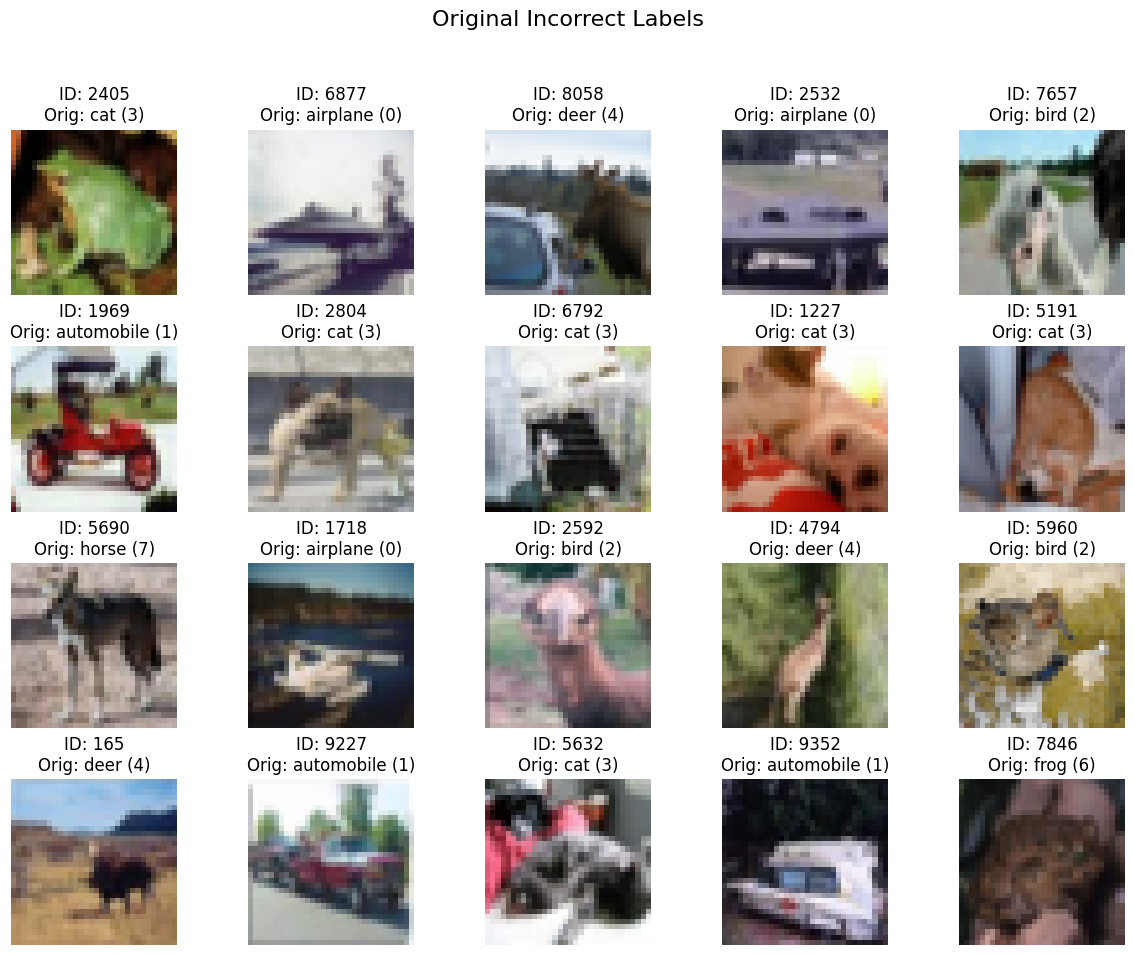


--- Test 데이터 레이블 수정 진행 ---
ID: 2405, Original: 3, Corrected to: 6
ID: 6877, Original: 0, Corrected to: 8
ID: 8058, Original: 4, Corrected to: 7
ID: 2532, Original: 0, Corrected to: 1
ID: 7657, Original: 2, Corrected to: 7
ID: 1969, Original: 1, Corrected to: 9
ID: 2804, Original: 3, Corrected to: 5
ID: 6792, Original: 3, Corrected to: 9
ID: 1227, Original: 3, Corrected to: 5
ID: 5191, Original: 3, Corrected to: 5
ID: 5690, Original: 7, Corrected to: 4
ID: 1718, Original: 0, Corrected to: 8
ID: 2592, Original: 2, Corrected to: 4
ID: 4794, Original: 4, Corrected to: 2
ID: 5960, Original: 2, Corrected to: 3
ID: 165, Original: 4, Corrected to: 2
ID: 9227, Original: 1, Corrected to: 9
ID: 5632, Original: 3, Corrected to: 5
ID: 9352, Original: 1, Corrected to: 9
ID: 7846, Original: 6, Corrected to: 3
ID: 6966, Original: 0, Corrected to: 8
ID: 5468, Original: 5, Corrected to: 3
총 22개의 레이블 수정 완료.


In [24]:
print("--- 수정 전 레이블 시각화 ---")
plt.figure(figsize=(12, 10))
plt.suptitle("Original Incorrect Labels", fontsize=16)
for i, idx in enumerate(wrong_ids[:20]): # 너무 많으면 일부만 표시
    original_label_index = y_test_og[idx][0]
    # original_label_index = np.argmax(y_test[idx]) # argmax를 사용해 원핫인코딩된 라벨에서 원래 라벨을 가져온다.
    plt.subplot(4, 5, i + 1)
    plt.imshow(x_test[idx])
    plt.title(f"ID: {idx}\nOrig: {cifar10_labels[original_label_index]} ({original_label_index})")
    plt.axis('off')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

# --- 실제 레이블 수정 ---
print("\n--- Test 데이터 레이블 수정 진행 ---")
num_corrected = 0
for idx, correct_label_index in wrong_to_correct_labels.items():
    original_label_index = y_test_og[idx][0]
    if original_label_index != correct_label_index:
        # One-hot 인코딩된 y_test 배열 수정
        y_test[idx] = to_categorical([correct_label_index], num_classes=10)[0]
        print(f"ID: {idx}, Original: {original_label_index}, Corrected to: {correct_label_index}")
        num_corrected += 1
    else:
        # 혹시 labelerrors.com 정보와 초기 데이터가 같은 경우 (그럴 가능성은 낮음)
        print(f"ID: {idx}, Label already correct: {original_label_index}")

print(f"총 {num_corrected}개의 레이블 수정 완료.")


--- 수정 후 레이블 시각화 ---


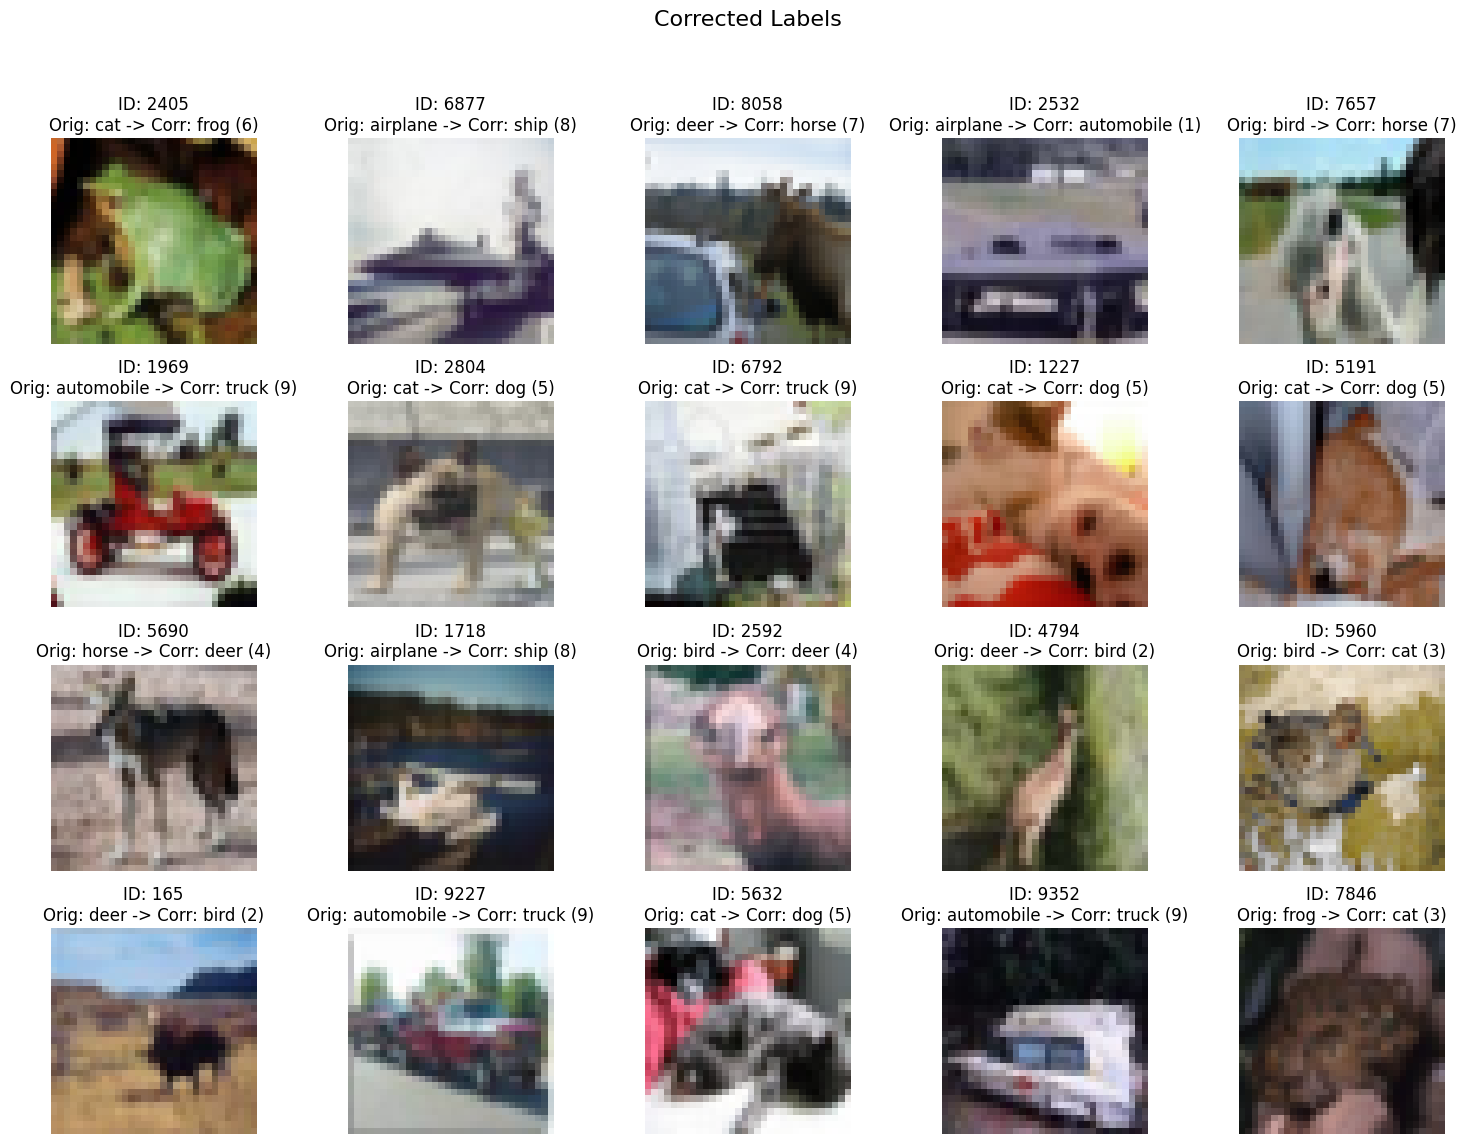

In [26]:
# 레이블 수정 후 시각화
print("\n--- 수정 후 레이블 시각화 ---")
y_test_corrected_indices = np.argmax(y_test, axis=1) # 수정된 y_test에서 인덱스 추출

plt.figure(figsize=(15, 12))
plt.suptitle("Corrected Labels", fontsize=16)
for i, idx in enumerate(wrong_ids[:20]): # 너무 많으면 일부만 표시
    corrected_label_index = y_test_corrected_indices[idx]
    original_label_index = y_test_og[idx][0] # 비교를 위해 원본 레이블도 가져옴
    plt.subplot(4, 5, i + 1)
    plt.imshow(x_test[idx])
    plt.title(f"ID: {idx}\nOrig: {cifar10_labels[original_label_index]} -> Corr: {cifar10_labels[corrected_label_index]} ({corrected_label_index})")
    plt.axis('off')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [29]:
# CNN 모델의 입력값으로 형태 변환
X_train = x_train.reshape(-1,32, 32, 3) # -1은 자동으로 계산된 첫번째 차원(샘플수), 데이터 크기가 변해도 코드 수정할 필요가 없다는 장점.
X_test = x_test.reshape(-1,32,32,3)
# y_train = tf.keras.utils.to_categorical(y_train)
# y_test = tf.keras.utils.to_categorical(y_test)

In [30]:
print(x_train[0].shape)

(32, 32, 3)


In [31]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size = 0.2)
print(X_train.shape)

(40000, 32, 32, 3)


In [32]:
y_train.shape
# 원-핫 인코딩된 2차원 배열 (48000,10) = (샘플수, 클래스 수)

(40000, 10)

아래 코드에 대한 설명

Keras Tuner를 커스터마이징하여:
1. 하이퍼파라미터로 모델을 생성
2. 모델을 학습
3. 성능을 평가
4. 결과를 반환

이 과정을 여러 번 반복하면서 최적의 하이퍼파라미터를 찾는다.

In [33]:
# hypermodel은 모델 구조를 정의하는 템플릿. 모델을 공유 및 재사용하기 위해 검색공간을 캡슐화한다.
# .build 메소드를 통해 빌드 후 하이퍼파라미터 튜닝 시작
# trial.hyperparameters는 이번 시도에서 사용할(Oracle이 찾아야 할) 하이퍼파라미터 값들. 이 값들로 실제 모델 제작

# kt.Tuner를 상속받아 Keras Tuner의 기능을 확장하는 커스텀 클래스
class DeepTuner(kt.Tuner):
    # trial인자는 현재 시도에 대한 정보를 담고 있다.
    # **fit_kwargs: 추가 학습 옵션들
    def run_trial(self, trial, X, y, validation_data, **fit_kwargs):
        model = self.hypermodel.build(trial.hyperparameters)
        model.fit(X, y, batch_size=trial.hyperparameters.Choice(
            'batch_size', [16, 32]), **fit_kwargs) # batch_size도 튜닝 대상 .Choice를 통해 [16,32] 중 선택됨


        X_val, y_val = validation_data
        eval_scores = model.evaluate(X_val, y_val) # 평가 결과
        print('test', model.metrics_names)
        print('test',eval_scores)
        return {name: value for name, value in zip(
            model.metrics_names,
            eval_scores)}

아래 코드에 대한 설명

이 함수는 하이퍼파라미터 튜닝을 위해:

- Conv2D 층의 개수와 필터 수를 자동으로 조정
- Dense 층의 개수와 노드 수를 자동으로 조정
- 최적의 모델 구조를 찾기 위한 템플릿 역할을 합니다

튜너가 이 함수를 여러 번 호출하면서 다양한 모델 구조를 시도하고, 가장 성능이 좋은 구조를 찾아낸다.

In [ ]:
# 기존 모델 함수
# hp: 하이퍼파라미터 객체를 통해 모델 구조를 유동적으로 변경
# def build_model(hp):
#     model = tf.keras.Sequential()
#     # hypermodel은 Input 지정이 필수! 넣고 싶은 모델에 대한 shape를 꼭 기재해야 한다.
#     # .shape[1:] 첫번째 차원(샘플수)를 제외한 나머지 차원
#     model.add(tf.keras.Input(shape = X_train.shape[1:], name = 'inputs'))

#     # Conv2D 층의 개수는 1-10개 사이에서 선택 (hp.Int로 정수 설정)
#     for i in range(hp.Int('num_layers', min_value=1, max_value=10)):
#               model.add(tf.keras.layers.Conv2D(hp.Int(
#                   'units_{i}'.format(i=i), min_value=32, max_value=128, step=5), (3,3),activation='relu'))

#     model.add(tf.keras.layers.Flatten())
#     # Dense 층의 개수는 1~3개, 노드 수(차원 수)를 [32, 64, 128, 256] 중 1개 선택
#     for i in range(hp.Int('n_connections', 1, 3)):
#         model.add(tf.keras.layers.Dense(hp.Choice(f'n_nodes',
#                                   values=[32,64,128, 256]), activation = 'relu'))

#     model.add(tf.keras.layers.Dense(10, activation='softmax', name = 'outputs'))

#     model.compile(optimizer = 'adam',loss='categorical_crossentropy',
#         metrics=['accuracy'])

#     return model

In [38]:
# CIFAR10 데이터셋 사용 모델 정의
def build_hyper_model(hp):
    model = Sequential()
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
    model.add(AveragePooling2D(pool_size=(2, 2)))
    model.add(BatchNormalization())

    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(AveragePooling2D(pool_size=(2, 2)))
    model.add(BatchNormalization())

    model.add(Flatten())
    model.add(Dense(256, activation='relu')) # Dense 유닛 수는 고정

    # Dropout 비율을 튜닝 대상으로 설정
    hp_dropout = hp.Float('dropout', min_value=0.2, max_value=0.5, step=0.1)
    model.add(Dropout(hp_dropout))

    model.add(Dense(10, activation='softmax'))

    # 학습률(Learning Rate)을 튜닝 대상으로 설정
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-3, 5e-4, 1e-4])

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=hp_learning_rate),
                  loss='categorical_crossentropy', # y_test가 one-hot 이므로
                  metrics=['accuracy'])
    return model

아래 코드에 대한 설명:

1. 베이지안 최적화를 사용해 하이퍼파라미터를 탐색
2. 2가지 다른 모델 구조를 시도
3. 각 모델을 3 에폭씩 학습
4. 정확도를 최대화하는 방향으로 최적의 모델 구조를 찾음

결과적으로 가장 성능이 좋은 모델 구조와 하이퍼파라미터 조합을 찾아준다.

In [44]:
# 앞서 만든 DeepTuner 클래스의 인스턴스 생성 = 하이퍼 파라미터 튜닝을 수행할 객체
my_keras_tuner = DeepTuner(
    # oracle: 하이퍼파라미터를 어떤 방식으로 탐색할지 결정하는 전략
    oracle=kt.oracles.BayesianOptimizationOracle(
        # objective=kt.Objective('accuracy', 'max'),
        objective=kt.Objective('compile_metrics', 'max'),   # 최적화할 지표, 해당 지표를 최적화하는 방향; max
        max_trials=3,                                       # 실험 횟수; 2개의 다른 모델 구조 시도
        seed=42),
    hypermodel=build_hyper_model,                                 # 앞서 정의한 모델 템플릿 함수 지정
    overwrite=True,                                         # True: 기존 결과를 삭제하고 새로 시작
    project_name='my_keras_tuner')                          # 결과가 저장될 폴더명

# 실제 튜닝 시
# 해당 모델 학습시간은 약 10분정도 걸립니다!
my_keras_tuner.search(
    X_train, y_train, validation_data=(X_val, y_val), epochs=3)

Trial 3 Complete [00h 00m 34s]
compile_metrics: 0.6543999910354614

Best compile_metrics So Far: 0.6543999910354614
Total elapsed time: 00h 01m 29s


In [45]:
# 튜닝 과정에서 찾은 최적의 하이퍼파라미터를 가져온다.
# 상위 10개(또는 max_trial 설정값만큼의) 결과 중, [0] = 최고성능 선택
best_hps = my_keras_tuner.get_best_hyperparameters(num_trials=10)[0]

# 최적의 하이퍼파라미터를 사용해 새로운 모델 생성 -> 이전에 정의한 build_model 함수에 최적의 설정값을 전달
model = build_hyper_model(best_hps)

model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_47 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_10            │ (None, 15, 15, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 15, 15, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_11            │ (None, 6, 6, 64)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 6, 6, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 612,426 (2.34 MB)

 Trainable params: 612,234 (2.34 MB)

 Non-trainable params: 192 (768.00 B)

In [46]:
model.fit(X_train, y_train, batch_size=32, epochs = 5)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.4007 - loss: 1.8645
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6257 - loss: 1.0688
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7040 - loss: 0.8513
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7554 - loss: 0.7011
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7975 - loss: 0.5812


In [43]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6441 - loss: 1.1257


[1.1347383260726929, 0.6435999870300293]

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


SavedModel: 텐서플로우가 공식적으로 지원하는 모델 저장방식  
- SavedModel: 모델, 가중치를 따로 구분해서 저장하는 방식  
- .h5파일은 모델의 가중치와 모델을 전부 하나의 파일로 관리하는 방식

SavedModel의 구성:
- saved_model.pb : pb는 프로토콜 버퍼를 의미하며 해당 파일은 내보낸 모델 그래프 구조를 포함하고 있습니다.
- variables : 내보낸 변수값이 있는 이진 파일과 내보낸 모델 그래프에 해당하는 체크포인트를 포함하고 있습니다
- assets : 내보낸 모델을 불러올 때 추가적인 파일이 필요한 경우 이 폴더에 파일이 생성됩니다.
이 방식으로 진행한다면 모델을 배포할 때 유리합니다.

Keras의 경우 .keras파일을 선호합니다. .keras파일은 .h5파일과 마찬가지로 가중치와 모델을 전부 하나의 파일로 관리합니다.

In [17]:
save_path = '/content/drive/MyDrive/ColabNotebooks/Aiffel_Ex06_hp_model'
fname = os.path.join(save_path, 'model')
# 모델을 TensorFlow의 SavedModel 형식으로 저장: 배포나 서빙에 적합
# 모델 구조, 가중치, 그래프 등 모든 정보를 포함
model.export(fname)

fname2 = os.path.join(save_path, 'ex06_model.keras')
# 모델을 Keras 형식으로 저장: 개발과 연구에 적합
# 모델 구조와 가중치를 저장
model.save(fname2)

Saved artifact at '/content/drive/MyDrive/ColabNotebooks/Aiffel_Ex06_hp_model/model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='inputs')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  139312833875792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139312713370320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139312713376656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139312640911952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139312640910224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139312640908880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139312640907728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139312640914640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139312640911184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139312640912720: TensorSpec(shape=(), dtype

In [ ]:
# !mkdir -p /content/drive/MyDrive/ColabNotebooks/Aiffel_Ex06_hp_model/model

In [18]:
## 모델 다운 받아서 다른곳에 가져가기용 압축
import shutil
shutil.make_archive('/content/drive/MyDrive/ColabNotebooks/Aiffel_Ex06_hp_model/model', 'zip', '/content/drive/MyDrive/ColabNotebooks/Aiffel_Ex06_hp_model/model')


'/content/drive/MyDrive/ColabNotebooks/Aiffel_Ex06_hp_model/model.zip'

# TF Serving

- 이건 WSL에서 따로 진행
- docker환경에서 따로진행


# TFLite

In [ ]:
load_path = '/content/aiffel/mlops/best_model/1/model.keras'

best_model = tf.keras.models.load_model(load_path)

In [ ]:
best_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_17 (Conv2D)              │ (None, 26, 26, 67)     │           670 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 24, 24, 77)     │        46,508 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 22, 22, 52)     │        36,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 20, 20, 127)    │        59,563 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 18, 18, 92)     │       105,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 16, 16, 122)    │       101,138 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 14, 14, 37)     │        40,663 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 12, 12, 32)     │        10,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 10, 10, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │       102,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ outputs (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,540,898 (5.88 MB)

 Trainable params: 513,632 (1.96 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,027,266 (3.92 MB)

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

Saved artifact at '/tmp/tmp8dgni78d'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='inputs')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  140501952447504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140501952450384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140501952449040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140501952461712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140501952453648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140501952447696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140501953215568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140501953208848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140501953203856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140501953208080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140501953209424: Tens

In [ ]:
with open('model.tflite', 'wb') as f:
  f.write(tflite_model)

In [ ]:
interpreter = tf.lite.Interpreter(model_content=tflite_model)

signatures = interpreter.get_signature_list()
print(signatures)

classify_lite = interpreter.get_signature_runner('serving_default')
print(classify_lite)

{'serving_default': {'inputs': ['inputs'], 'outputs': ['output_0']}}


# FASTAPI 활용

In [ ]:
!pip install fastapi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.8 MB/s eta 0:00:00


In [ ]:
from fastapi import FastAPI
from pydantic import BaseModel
import numpy as np
import tensorflow as tf

load_path = '/content/aiffel/mlops/best_model/1/model.keras'

# 모델 로드 (.keras 또는 .h5 둘 다 가능)
model = tf.keras.models.load_model(load_path)

app = FastAPI()

# 입력 스키마 정의 (28x28 배열)
class InputData(BaseModel):
    image: list  # shape: [28][28], 흑백 이미지

@app.post("/predict")
def predict(data: InputData):
    # 입력 데이터를 numpy 배열로 변환
    img = np.array(data.image, dtype=np.float32).reshape(1, 28, 28, 1)

    # 예측
    pred = model.predict(img)
    predicted_class = int(np.argmax(pred[0]))

    return {"prediction": predicted_class, "confidence": float(np.max(pred[0]))}

In [ ]:
!pip install fastapi uvicorn nest-asyncio pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 5.1 MB/s eta 0:00:00


In [ ]:
!ngrok config add-authtoken 2ZqtCc5YdpVlQ8L4xTsEUfhCmtt_dqaC9SPiqCt2MjDGhYJx

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
import nest_asyncio
import uvicorn
from pyngrok import ngrok

# Colab에서 중복 event loop 방지
nest_asyncio.apply()

# ngrok URL 만들기
public_url = ngrok.connect(8000)
print(f"Your app is live at: {public_url}")

# 서버 실행
uvicorn.run(app, host="0.0.0.0", port=8000)

INFO:     Started server process [804]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


Your app is live at: NgrokTunnel: "https://d5de-34-124-249-205.ngrok-free.app" -> "http://localhost:8000"
INFO:     220.117.157.36:0 - "GET / HTTP/1.1" 404 Not Found
INFO:     220.117.157.36:0 - "GET /favicon.ico HTTP/1.1" 404 Not Found
INFO:     220.117.157.36:0 - "GET /docs HTTP/1.1" 200 OK
INFO:     220.117.157.36:0 - "GET /openapi.json HTTP/1.1" 200 OK
INFO:     220.117.157.36:0 - "POST /predict HTTP/1.1" 500 Internal Server Error


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/uvicorn/protocols/http/h11_impl.py", line 403, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/fastapi/applications.py", line 1054, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.11/dist-packages/starlette/applications.py", line 112, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.11/dist-packages/starlette/middleware/errors.py", line 187, in __call__
    raise exc
  File "/usr/local/lib/python3.11/dist-packages/starlette/middleware/errors.py",